<a href="https://colab.research.google.com/github/lejuin/aidl_fingerspelling/blob/main/notebooks/Run_git_code_in_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import git repo

In [2]:
!git clone https://github.com/lejuin/fingerspelling_asl.git
#!git clone -b from_bucket https://github.com/lejuin/fingerspelling_asl.git

Cloning into 'fingerspelling_asl'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 94 (delta 29), reused 90 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 489.13 KiB | 5.96 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [3]:
!pip install -r fingerspelling_asl/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 81.1 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
import sys
sys.path.insert(0,'fingerspelling_asl')

In [49]:
import pandas as pd
from google.colab import userdata

# Setup for Colab

In [5]:
!curl ipinfo.io

{
  "ip": "34.169.23.176",
  "hostname": "176.23.169.34.bc.googleusercontent.com",
  "city": "The Dalles",
  "region": "Oregon",
  "country": "US",
  "loc": "45.5946,-121.1787",
  "org": "AS396982 Google LLC",
  "postal": "97058",
  "timezone": "America/Los_Angeles",
  "readme": "https://ipinfo.io/missingauth"
}

## Configuration to load from bucket

In [ ]:
from google.colab import auth
PROJECT_ID = "firststepsgc"
#PROJECT_ID = "buoyant-purpose-479417-t8"
auth.authenticate_user(project_id=PROJECT_ID)

BUCKET_NAME = "aidl_asl_datasets"

In [ ]:
args_dict = {
  'data_dir': f"gs://{BUCKET_NAME}/asl-fingerspelling",
  'train_csv': "train.csv",
  'run_name': None,
  'logdir':"artifacts/logs",
  'max_frames':160,
  'epochs':5,
  'batch_size':4,
  'lr':1e-3,
  'hidden_dim':128,
  'val_ratio':0.2,
  'seed':42,
  'train_size':200,
  'val_size':200,
  'max_phrase_len':0,
  'overfit_subset':0,
  'use_wandb':True,
  'wandb_project':"fingerspelling_asl",
  'wandb_entity':None,
  'wandb_run_name':None,
  'wandb_mode':"online",
  'wandb_tags':""
}

## To download and run locally

In [7]:
!pip install kagglehub==1.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [1]:
import kagglehub
print(kagglehub.__version__)

1.0.0


In [14]:
from pathlib import Path

In [3]:
train_path =  kagglehub.competition_download('asl-fingerspelling', path="train.csv")
voc_path =  kagglehub.competition_download('asl-fingerspelling', path="character_to_prediction_index.json")

100%|██████████| 1.20M/1.20M [00:00<00:00, 101MB/s]

Extracting zip of train.csv...


In [36]:
supp_path =  kagglehub.competition_download('asl-fingerspelling', path="supplemental_metadata.csv")

100%|██████████| 840k/840k [00:00<00:00, 88.9MB/s]

Extracting zip of supplemental_metadata.csv...


In [4]:
voc_path =  kagglehub.competition_download('asl-fingerspelling', path="character_to_prediction_index.json")

100%|██████████| 405/405 [00:00<00:00, 930kB/s]


In [10]:
train_pdf =pd.read_csv(train_path)
print("train_pdf.shape", train_pdf.shape)
train_pdf.head()

train_pdf.shape (67208, 5)


,path,file_id,sequence_id,participant_id,phrase
0,train_landmarks/5414471.parquet,5414471,1816796431,217,3 creekhouse
1,train_landmarks/5414471.parquet,5414471,1816825349,107,scales/kuhaylah
2,train_landmarks/5414471.parquet,5414471,1816909464,1,1383 william lanier
3,train_landmarks/5414471.parquet,5414471,1816967051,63,988 franklin lane
4,train_landmarks/5414471.parquet,5414471,1817123330,89,6920 northeast 661st road


In [37]:
supp_pdf = pd.read_csv(supp_path)
print("supp_pdf.shape", supp_pdf.shape)
supp_pdf.head()

supp_pdf.shape (52958, 5)


,path,file_id,sequence_id,participant_id,phrase
0,supplemental_landmarks/33432165.parquet,33432165,1535467051,251,coming up with killer sound bites
1,supplemental_landmarks/33432165.parquet,33432165,1535499058,239,we better investigate this
2,supplemental_landmarks/33432165.parquet,33432165,1535530550,245,interesting observation was made
3,supplemental_landmarks/33432165.parquet,33432165,1535545499,38,victims deserve more redress
4,supplemental_landmarks/33432165.parquet,33432165,1535585216,254,knee bone is connected to the thigh bone


In [21]:
compet_dir = Path(train_path).parent

In [22]:
list((compet_dir / "train_landmarks").glob("*"))

[PosixPath('/root/.cache/kagglehub/competitions/asl-fingerspelling/train_landmarks/5414471.parquet')]

In [11]:
#downloaded_files = [filename.name for filename in gc_bucket.list_blobs()]
#missing_files = [f for f in train_pdf['path'].unique() if f"asl-fingerspelling/{f}" not in bucket_files]
missing_files = [f for f in train_pdf['path'].unique()]
print(f"Number of missing files: {len(missing_files)}")
missing_files[:5]

Number of missing files: 68


['train_landmarks/5414471.parquet',
 'train_landmarks/105143404.parquet',
 'train_landmarks/128822441.parquet',
 'train_landmarks/149822653.parquet',
 'train_landmarks/152029243.parquet']

In [12]:
landmark_paths = {}

file_id = 5414471
landmark_paths[file_id] = kagglehub.competition_download('asl-fingerspelling', path=f'train_landmarks/{file_id}.parquet')

100%|██████████| 1.28G/1.28G [00:20<00:00, 67.3MB/s]

Extracting zip of 5414471.parquet...


In [72]:
# To download data and load locally
args_dict = {
  'data_dir': compet_dir,
  'train_csv': "train.csv",
  'run_name': "single_file_lstm",
  'logdir':"artifacts/logs",
  'max_frames':160,
  'epochs':3,
  'batch_size':4,
  'lr':1e-3,
  'hidden_dim':64,
  'proj_dim': 32,
  #'tcn_kernels': "3,3,3",
  'rnn_layers': 2,
  'rnn_type': 'lstm',
  'val_ratio':0.2,
  'seed':42,
  'train_size':200,
  'val_size':200,
  'use_supplemental': False,
  'max_phrase_len':20,
  'overfit_subset':0,
  'eval_train_metrics': True,
  'use_wandb':True,
  'wandb_project':"fingerspelling_asl",
  'wandb_entity':None,
  'wandb_run_name':None,
  'wandb_mode':"online",
  'wandb_tags':"lstm,bidir,tiny_subset,letters_only"
}

### [temp]: attemp to pre-compute dataset

In [89]:
tmp = df.head().copy()
tmp

,path,file_id,sequence_id,participant_id,phrase
16,train_landmarks/5414471.parquet,5414471,1817362238,231,leona owens
19,train_landmarks/5414471.parquet,5414471,1817438012,202,kati castro
30,train_landmarks/5414471.parquet,5414471,1817781680,254,jami mcfarland
53,train_landmarks/5414471.parquet,5414471,1818444969,227,tomeka salinas
81,train_landmarks/5414471.parquet,5414471,1819369909,141,polcathejourney


In [82]:
from src.data.dataset import read_right_hand_sequence

In [83]:
x = read_right_hand_sequence(landmark_paths[file_id], 1817362238)

In [85]:
type(x)

numpy.ndarray

In [87]:
x.shape

(78, 63)

In [92]:
import numpy as np

# Save the array 'x' to a .npy file
np.save('x_data.npy', x)
print("Array 'x' saved to x_data.npy")

# To load the array back:
loaded_x = np.load('x_data.npy')
print("Array loaded from x_data.npy with shape:", loaded_x.shape)
print("Type of loaded array:", type(loaded_x))

Array 'x' saved to x_data.npy
Array loaded from x_data.npy with shape: (78, 63)
Type of loaded array: <class 'numpy.ndarray'>


In [95]:
!ls -lh

total 36K
drwxr-xr-x 4 root root 4.0K Mar 10 22:51 artifacts
drwxr-xr-x 6 root root 4.0K Mar 10 21:04 fingerspelling_asl
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data
drwxr-xr-x 4 root root 4.0K Mar 10 23:12 wandb
-rw-r--r-- 1 root root  20K Mar 10 23:39 x_data.npy


## Preparing args

In [73]:
# setting params
class Args:
    def __init__(self, dict_args):
        for key, value in dict_args.items():
            setattr(self, key, value)

args = Args(args_dict)

args.train_csv

'train.csv'

In [25]:
from src.train import *

In [27]:
import os
import json
import argparse
#from fsspec.implementations.local import LocalFileSystem
from datetime import datetime
from typing import List, Tuple

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import re

try:
    import wandb
except ImportError:
    wandb = None

from src.models.tcn_bilstm import TCNBiRNN
from src.models.embedded_rnn import EmbeddedRNN
from src.data.dataset import ASLRightHandDataset, collate_fn
from src.data.vocab import build_ctc_vocab, encode_phrase
from src.utils.metrics import evaluate_metrics, ctc_greedy_decode

# Reproduce main function

In [ ]:
# from_bucket branch version
from fsspec.implementations.local import LocalFileSystem
from src.utils.filesystem import get_filesystem, join_path

fs = get_filesystem(args.data_dir)
train_csv = args.train_csv

if not os.path.isabs(train_csv):
    train_csv = join_path(fs, args.data_dir, train_csv)
vocab_json =join_path(fs,args.data_dir, "character_to_prediction_index.json")
landmarks_dir = join_path(fs, args.data_dir, "train_landmarks")

if not fs.exists(train_csv):
    raise FileNotFoundError(f"Missing {train_csv}")
if not fs.exists(vocab_json):
    raise FileNotFoundError(f"Missing {vocab_json}")
if not fs.isdir(landmarks_dir):
    raise FileNotFoundError(f"Missing folder {landmarks_dir}")


In [28]:
# main branch version
train_csv = args.train_csv
if not os.path.isabs(train_csv):
    train_csv = os.path.join(args.data_dir, train_csv)
vocab_json = os.path.join(args.data_dir, "character_to_prediction_index.json")
landmarks_dir = os.path.join(args.data_dir, "train_landmarks")

if not os.path.exists(train_csv):
    raise FileNotFoundError(f"Missing {train_csv}")
if not os.path.exists(vocab_json):
    raise FileNotFoundError(f"Missing {vocab_json}")
if not os.path.isdir(landmarks_dir):
    raise FileNotFoundError(f"Missing folder {landmarks_dir}")

In [29]:
 # Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [31]:
# Load vocab mapping (char -> id) in CTC-compatible form
letter_to_int, int_to_letter, blank_id = build_ctc_vocab(vocab_json) #, fs)

In [32]:
# Load train.csv
df = pd.read_csv(train_csv)
required_cols = {"file_id", "sequence_id", "participant_id", "phrase"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"train.csv is missing columns: {missing}")

df.shape

(67208, 5)

In [34]:
# Filter by parquets you actually downloaded
have_ids = existing_file_ids(landmarks_dir) #, fs)
if not have_ids:
    raise ValueError(
        f"No parquet files found in {landmarks_dir}. "
        f"Download a few like 0.parquet, 1.parquet, etc."
    )
df = df[df["file_id"].isin(have_ids)].copy()
print(f"Rows after filtering to available parquets ({len(have_ids)} file_ids): {len(df)}")

Rows after filtering to available parquets (1 file_ids): 1000


In [35]:
_clean_re = re.compile(r'^[a-z ]+$')
df["phrase"] = df["phrase"].astype(str).str.lower().str.strip()
df = df[df["phrase"].apply(lambda x: bool(_clean_re.match(x)) and len(x) > 0)].copy()
print(f"Rows after filtering to letters-only phrases: {len(df)}")

Rows after filtering to letters-only phrases: 121


In [38]:
from src.data.dataset import read_right_hand_sequence, count_valid_frames
print("Pre-filtering sequences with no right-hand landmarks...")
valid_mask = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Checking landmarks", leave=False):
    fid = int(row["file_id"])
    sid = int(row["sequence_id"])
    lm_dir = landmarks_dir
    if "_landmarks_dir" in row.index:
        lm_dir = row["_landmarks_dir"]
    ppath = os.path.join(lm_dir, f"{fid}.parquet")
    if not os.path.exists(ppath):
        valid_mask.append(False)
        continue
    X_raw = read_right_hand_sequence(ppath, sid)
    n_valid = count_valid_frames(X_raw)
    valid_mask.append(n_valid > 0)
df = df[valid_mask].copy()
print(f"Rows after filtering no-data sequences: {len(df)}")

Pre-filtering sequences with no right-hand landmarks...


Rows after filtering no-data sequences: 102


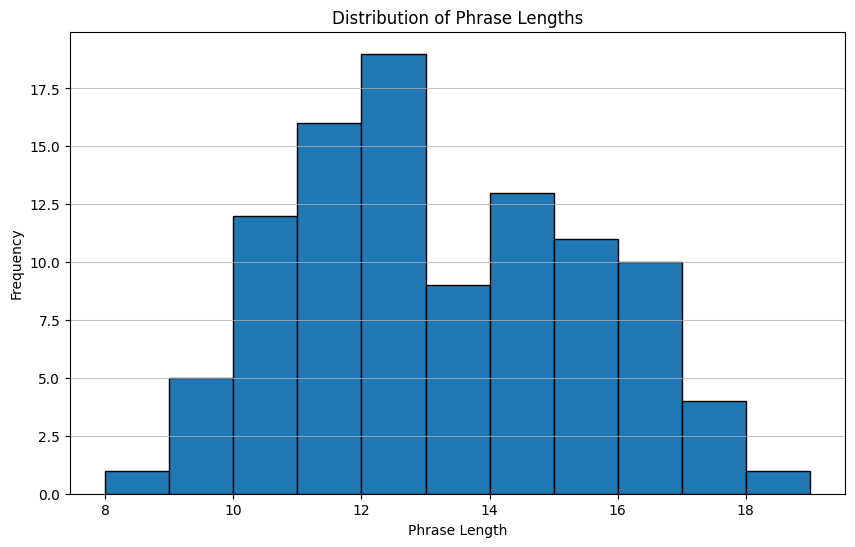

In [40]:
import matplotlib.pyplot as plt

phrase_lengths = df["phrase"].astype(str).str.len()

plt.figure(figsize=(10, 6))
plt.hist(phrase_lengths, bins=range(min(phrase_lengths), max(phrase_lengths) + 2), edgecolor='black')
plt.title('Distribution of Phrase Lengths')
plt.xlabel('Phrase Length')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [39]:
if args.max_phrase_len > 0:
    df = df[df["phrase"].astype(str).str.len() <= args.max_phrase_len].copy()
    print(f"Rows after filtering by max_phrase_len={args.max_phrase_len}: {len(df)}")
    if len(df) == 0:
        raise ValueError("No rows left after max_phrase_len filtering.")

Rows after filtering by max_phrase_len=20: 101


In [41]:
if args.overfit_subset > 0:
    n_subset = min(args.overfit_subset, len(df))
    overfit_df = df.sample(n=n_subset, random_state=args.seed).copy()
    overfit_df["encoded"] = overfit_df["phrase"].apply(lambda x: encode_phrase(str(x), letter_to_int))
    train_df = overfit_df.copy()
    val_df = overfit_df.copy()
    print(f"Overfit mode enabled: using same {n_subset} samples for train and val")
else:
    # Split by participant_id
    train_df, val_df = split_by_participant(df, val_ratio=args.val_ratio, seed=args.seed)

    # Encode targets
    train_df["encoded"] = train_df["phrase"].apply(lambda x: encode_phrase(str(x), letter_to_int))
    val_df["encoded"] = val_df["phrase"].apply(lambda x: encode_phrase(str(x), letter_to_int))

    # Sample small subsets for local dev
    if args.train_size and args.train_size < len(train_df):
        train_df = train_df.sample(args.train_size, random_state=args.seed)
    if args.val_size and args.val_size < len(val_df):
        val_df = val_df.sample(args.val_size, random_state=args.seed)

print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)}")

Train samples: 82 | Val samples: 19


In [44]:
# Datasets / loaders
#train_ds = ASLRightHandDataset(train_df, landmarks_dir=landmarks_dir, max_frames=args.max_frames)
#val_ds = ASLRightHandDataset(val_df, landmarks_dir=landmarks_dir, max_frames=args.max_frames)
train_ds = ASLRightHandDataset(train_df, landmarks_dir=landmarks_dir, max_frames=args.max_frames, use_per_row_dir=args.use_supplemental, training=True)
val_ds = ASLRightHandDataset(val_df, landmarks_dir=landmarks_dir, max_frames=args.max_frames, use_per_row_dir=args.use_supplemental, training=False)

train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=args.batch_size, shuffle=False, collate_fn=collate_fn, num_workers=0)

In [68]:
# Model — 63 landmarks + 63 delta features = 126
input_dim = 126
# output_dim must match max id + 1 (including blank=0)
output_dim = max(int_to_letter.keys()) + 1

model = EmbeddedRNN(input_dim, args.hidden_dim, output_dim).to(device)

In [46]:
criterion = nn.CTCLoss(blank=blank_id, zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3,
)

In [47]:
# Tracking setup
run_name = args.run_name or datetime.now().strftime("run_%Y%m%d_%H%M%S")

# TensorBoard
log_path = os.path.join(args.logdir, run_name)
os.makedirs(log_path, exist_ok=True)
writer = SummaryWriter(log_path)
print(f"TensorBoard logdir: {log_path}")

TensorBoard logdir: artifacts/logs/single_file_lstm


In [77]:
run_name = "single_file_lstm_2"

In [78]:
import os

# Set the WANDB_API_KEY environment variable
# You should set your API key in Colab secrets under the name 'WANDB_API_KEY'
if 'WANDB_API_KEY' not in os.environ:
    os.environ['WANDB_API_KEY'] = userdata.get('WANDB_API_KEY')

wandb_enabled = args.use_wandb and args.wandb_mode != "disabled"
if args.use_wandb and wandb is None:
    raise ImportError("wandb is not installed. Run: pip install wandb")

if wandb_enabled:
    # Initialize wandb by logging in with the API key
    # This prevents interactive prompts for the API key
    wandb.login(key=os.environ.get('WANDB_API_KEY'))

    wandb.init(
        project=args.wandb_project,
        entity=args.wandb_entity,
        name=args.wandb_run_name or run_name,
        config=vars(args),
        mode=args.wandb_mode,
        tags=parse_wandb_tags(args.wandb_tags)
    )

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [63]:
X, Y, in_lens, tar_lens = next(iter(train_loader))
X.shape

torch.Size([4, 160, 126])

In [69]:
#model = EmbeddedRNN(126, args.hidden_dim, output_dim).to(device)
model

EmbeddedRNN(
  (rnn): LSTM(126, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=28, bias=True)
  (log_softmax): LogSoftmax(dim=2)
)

In [70]:
model(X, in_lens)

tensor([[[-3.2581, -3.3056, -3.2775,  ..., -3.3854, -3.3672, -3.3107],
         [-3.2113, -3.3215, -3.2626,  ..., -3.3464, -3.3595, -3.3405],
         [-3.2106, -3.3417, -3.2605,  ..., -3.3804, -3.3384, -3.3383],
         [-3.2455, -3.3710, -3.2731,  ..., -3.3525, -3.3745, -3.3339]],

        [[-3.2157, -3.3038, -3.2813,  ..., -3.3732, -3.3485, -3.3369],
         [-3.1984, -3.3769, -3.2462,  ..., -3.3449, -3.3936, -3.2707],
         [-3.1918, -3.2755, -3.2830,  ..., -3.3885, -3.3562, -3.3299],
         [-3.2140, -3.3018, -3.2506,  ..., -3.3629, -3.3609, -3.3344]],

        [[-3.2331, -3.2969, -3.2511,  ..., -3.3623, -3.3482, -3.3261],
         [-3.1766, -3.3287, -3.2569,  ..., -3.3632, -3.3614, -3.3570],
         [-3.1773, -3.3099, -3.2705,  ..., -3.4059, -3.3739, -3.3793],
         [-3.2316, -3.3440, -3.2329,  ..., -3.3298, -3.3652, -3.2931]],

        ...,

        [[-3.1934, -3.3937, -3.2565,  ..., -3.3128, -3.3676, -3.3492],
         [-3.2523, -3.3330, -3.2794,  ..., -3.3133, -3.33

In [79]:
global_step = 0
best_val_cer = float("inf")
for epoch in range(args.epochs):
    model.train()
    losses = []
    blank_ratios = []
    in_tar_ratios = []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{args.epochs}", leave=False)

    for batch in pbar:
        if batch is None:
            continue
        X, Y, in_lens, tar_lens = batch
        X = X.to(device)

        optimizer.zero_grad()
        log_probs = model(X, in_lens)  # (T, B, C)

        loss = criterion(log_probs, Y, in_lens, tar_lens)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"WARNING: skipping batch with loss={loss.item()}")
            optimizer.zero_grad()
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        # Simple diagnostics: blank-token dominance and input/target length ratio.
        with torch.no_grad():
            pred_ids = torch.argmax(log_probs, dim=2)  # (T, B)
            blank_mask = (pred_ids == blank_id).float()
            blank_ratios.append(float(blank_mask.mean().item()))
            ratio_vals = (in_lens.float() / tar_lens.float().clamp_min(1.0)).detach().cpu()
            in_tar_ratios.append(float(ratio_vals.mean().item()))

        loss_val = float(loss.item())
        losses.append(loss_val)

        writer.add_scalar("loss/train_step", loss_val, global_step)
        if wandb_enabled:
            wandb.log({"loss/train_step": loss_val, "global_step": global_step}, step=global_step)

        global_step += 1
        pbar.set_postfix(loss=loss_val)

    mean_train_loss = float(sum(losses) / max(1, len(losses)))
    mean_blank_ratio = float(sum(blank_ratios) / max(1, len(blank_ratios)))
    mean_in_tar_ratio = float(sum(in_tar_ratios) / max(1, len(in_tar_ratios)))
    writer.add_scalar("loss/train", mean_train_loss, epoch)
    writer.add_scalar("diag/blank_ratio_pred", mean_blank_ratio, epoch)
    writer.add_scalar("diag/input_target_len_ratio", mean_in_tar_ratio, epoch)
    print(f"Epoch {epoch + 1}: train loss={mean_train_loss:.4f}")

    train_metrics = None
    if args.eval_train_metrics:
        train_metrics = evaluate_metrics(
            model,
            train_loader,
            int_to_letter=int_to_letter,
            device=device,
            blank_id=blank_id,
        )
        writer.add_scalar("cer/train", train_metrics["cer"], epoch)
        writer.add_scalar("wer/train", train_metrics["wer"], epoch)
        writer.add_scalar("sequence_accuracy/train", train_metrics["sequence_accuracy"], epoch)
        writer.add_scalar("avg_edit_distance/train", train_metrics["avg_edit_distance"], epoch)

    scheduler.step(mean_train_loss)

    # Validation loss
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            if batch is None:
                continue
            X, Y, in_lens, tar_lens = batch
            X = X.to(device)
            log_probs = model(X, in_lens)
            val_loss = criterion(log_probs, Y, in_lens, tar_lens)
            val_losses.append(val_loss.item())
    mean_val_loss = float(sum(val_losses) / max(1, len(val_losses)))
    writer.add_scalar("loss/val", mean_val_loss, epoch)

    # Validation metrics
    metrics = evaluate_metrics(
        model,
        val_loader,
        int_to_letter=int_to_letter,
        device=device,
        blank_id=blank_id,
    )

    writer.add_scalar("cer/val", metrics["cer"], epoch)
    writer.add_scalar("wer/val", metrics["wer"], epoch)
    writer.add_scalar("sequence_accuracy/val", metrics["sequence_accuracy"], epoch)
    writer.add_scalar("avg_edit_distance/val", metrics["avg_edit_distance"], epoch)

    if wandb_enabled:
        payload = {
            "epoch": epoch + 1,
            "loss/train": mean_train_loss,
            "loss/val": mean_val_loss,
            "diag/blank_ratio_pred": mean_blank_ratio,
            "diag/input_target_len_ratio": mean_in_tar_ratio,
            "cer/val": metrics["cer"],
            "wer/val": metrics["wer"],
            "sequence_accuracy/val": metrics["sequence_accuracy"],
            "avg_edit_distance/val": metrics["avg_edit_distance"],
            "global_step": global_step,
        }
        if train_metrics is not None:
            payload.update(
                {
                    "cer/train": train_metrics["cer"],
                    "wer/train": train_metrics["wer"],
                    "sequence_accuracy/train": train_metrics["sequence_accuracy"],
                    "avg_edit_distance/train": train_metrics["avg_edit_distance"],
                }
            )
        wandb.log(payload, step=global_step)

    if train_metrics is not None:
        print(
            f"Epoch {epoch + 1}: "
            f"train CER={train_metrics['cer']:.4f} | "
            f"WER={train_metrics['wer']:.4f} | "
            f"ExactMatch={train_metrics['sequence_accuracy']:.4f} | "
            f"AvgEditDist={train_metrics['avg_edit_distance']:.4f}"
        )
    print(
        f"Epoch {epoch + 1}: "
        f"diag blank_ratio_pred={mean_blank_ratio:.4f} | "
        f"input/target ratio={mean_in_tar_ratio:.2f}"
    )

    print(
        f"Epoch {epoch + 1}: "
        f"val loss={mean_val_loss:.4f} | "
        f"val CER={metrics['cer']:.4f} | "
        f"WER={metrics['wer']:.4f} | "
        f"ExactMatch={metrics['sequence_accuracy']:.4f} | "
        f"AvgEditDist={metrics['avg_edit_distance']:.4f}"
    )

    # Save best checkpoint (by val CER)
    if metrics["cer"] < best_val_cer:
        best_val_cer = metrics["cer"]
        ckpt_path = os.path.join("artifacts", "models", f"{run_name}_best.pt")
        os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "config": vars(args),
            },
            ckpt_path,
        )
        print(f"  -> Saved best model (val CER={best_val_cer:.4f})")

    # Save latest checkpoint (for resuming)
    ckpt_path = os.path.join("artifacts", "models", f"{run_name}_latest.pt")
    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": vars(args),
        },
        ckpt_path,
    )


Epoch 1: train loss=13.8264
Epoch 1: train CER=0.9347 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.0476
Epoch 1: diag blank_ratio_pred=0.1676 | input/target ratio=5.25
Epoch 1: val loss=14.6239 | val CER=0.9025 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=11.8333
  -> Saved best model (val CER=0.9025)


Epoch 2: train loss=12.5655
Epoch 2: train CER=0.9397 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.1111
Epoch 2: diag blank_ratio_pred=0.1447 | input/target ratio=4.82
Epoch 2: val loss=14.6239 | val CER=0.9025 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=11.8333


Epoch 3: train loss=13.5605
Epoch 3: train CER=0.9328 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=12.0968
Epoch 3: diag blank_ratio_pred=0.1684 | input/target ratio=5.15
Epoch 3: val loss=14.6239 | val CER=0.9025 | WER=1.0000 | ExactMatch=0.0000 | AvgEditDist=11.8333


In [75]:
if wandb_enabled:
    log_examples_to_wandb(
        model=model,
        dataloader=val_loader,
        int_to_letter=int_to_letter,
        device=device,
        blank_id=blank_id,
        global_step=global_step,
        split_name="val",
        n_examples=5,
    )

writer.close()
if wandb_enabled:
    wandb.finish()

Logging 5 GT/PRED examples (val):
[1] GT: toby larson
    PRED: lallll
[2] GT: chasity doyle
    PRED: alalalalnaln
[3] GT: lawanda middleton
    PRED: llllllll
[4] GT: vivian nicholson
    PRED: llll
[5] GT: bernard oneill
    PRED: lalll


avg_edit_distance/train,▁▆█
avg_edit_distance/val,▁▁▁
cer/train,▁█▅
cer/val,▁▁▁
diag/blank_ratio_pred,▁█▅
diag/input_target_len_ratio,▁█▄
epoch,▁▅█
global_step,▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
loss/train,▁█▄
loss/train_step,▃▁▆▂▃▃▆▃▅▄▂▂▃▃▅▅▁▆▄▄█▃▆▁▅▆▄█▆▄▃▃▅▄▅▁▄▃▄▂
+4,...
